# Homeowners Insurance Precision Pricing
## Actuarial Loss Modeling: GLM + GBM, with Snowflake

This notebook walks through the end-to-end actuarial pricing workflow for a
**homeowners insurance** portfolio (~678,000 policies).

**Modeling strategy**

| Step | Model | Distribution | Target |
|------|-------|--------------|--------|
| 1 | Frequency GLM | Poisson | Claims per policy-year |
| 2 | Severity GLM | Gamma | Average cost given a claim |
| 3a | Product model | Poisson × Gamma | Pure premium (indirect) |
| 3b | Tweedie GLM | Tweedie (p≈1.9) | Pure premium (direct) |
| 4 | GBM | — | Pure premium (non-linear benchmark) |

**Key actuarial concept:** The *pure premium* = expected total claim cost per unit
of exposure. It is the foundation of risk-based pricing.

**Actuarial diagnostics produced**
- Double-lift chart (decile predicted vs. observed — is the model well-ordered?)
- Lorenz / Gini curve (ranking ability — how well does the model discriminate risk?)

Data is loaded directly from Snowflake:
`COUNTRY_BANK_DEMO_DB.ACTUARIAL_PRICING.HOME_POLICY_FREQ / HOME_POLICY_SEV`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Snowpark Connect for Apache Spark — PySpark code runs on Snowflake compute
from snowflake.snowpark_connect import init_spark_session
from snowflake.snowpark_connect.snowflake_session import SnowflakeSession

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.linear_model import TweedieRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_tweedie_deviance, auc

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded.")
print(f"JAVA_HOME = {os.environ.get('JAVA_HOME', 'NOT SET — see .env file')}")

2026-05-20 08:56:48,831 - snowflake_connect_server - WARNING - [Thread 8371592832] - OpenTelemetry basic modules not available: No module named 'opentelemetry'


Libraries loaded.
JAVA_HOME = /opt/homebrew/opt/openjdk@21/libexec/openjdk.jdk/Contents/Home


## 1. Load Data from Snowflake via Snowpark Connect

**Snowpark Connect for Apache Spark** — write standard PySpark DataFrame code,
run it on Snowflake's compute engine. No Spark cluster to manage.

In [2]:

try:
    # From SPCS Service, session is already configured
    from snowflake.snowpark.context import get_active_session
    snowpark_session = get_active_session()
except Exception:
    # Local IDE, supply session parameters
    from snowflake.snowpark import Session
    snowpark_session = Session.builder.configs({
        "connection_name": "default",
        "role":      "COUNTRY_BANK_DEMO_ROLE",
        "warehouse": "COMPUTE_WH",
        "database":  "COUNTRY_BANK_DEMO_DB",
        "schema":    "ACTUARIAL_PRICING",
    }).create()

snowpark_session.sql("USE ROLE COUNTRY_BANK_DEMO_ROLE").collect()
snowpark_session.sql("USE WAREHOUSE COMPUTE_WH").collect()
snowpark_session.sql("USE DATABASE COUNTRY_BANK_DEMO_DB").collect()
snowpark_session.sql("USE SCHEMA ACTUARIAL_PRICING").collect()

spark = init_spark_session() # Replaces getOrCreate

2026-05-20 08:56:54,891 - snowflake_connect_server - INFO - [Thread 8371592832] - JAVA_HOME=/opt/homebrew/opt/openjdk@21/libexec/openjdk.jdk/Contents/Home
2026-05-20 08:56:54,900 - snowflake_connect_server - INFO - [Thread 8371592832] - JVM classpath: 29 jars included, 28 dropped (set SCOS_JVM_CLASSPATH_FULL=1 to restore the full classpath).
2026-05-20 08:56:55,599 - snowflake_connect_server - INFO - [Thread 12948926464] - Configuring session <snowflake.snowpark.session.Session: account="SFSENORTHAMERICA-BFENKER_AWS1", role="COUNTRY_BANK_DEMO_ROLE", database="COUNTRY_BANK_DEMO_DB", schema="ACTUARIAL_PRICING", warehouse="COMPUTE_WH">
2026-05-20 08:56:55,599 - snowflake_connect_server - INFO - [Thread 12948926464] - Telemetry initialized with <class 'snowflake.snowpark_connect.utils.telemetry.ClientTelemetrySink'>
You might have more than one threads sharing the Session object trying to update eliminate_numeric_sql_value_cast_enabled. Updating this while other tasks are running can poten

In [3]:
from pyspark.sql import functions as F

# Read from Snowflake table (within Database, Schema set previously)
freq_sdf = spark.read.table("HOME_POLICY_FREQ")

# Joins and other manipulation push compute to Snowflake warehouse
sev_sdf  = (
    spark.read.table("HOME_POLICY_SEV")
    .groupBy("POLICY_ID")
    .agg(F.sum("CLAIM_AMOUNT").alias("CLAIM_AMOUNT"))
)

policy_sdf = (
    freq_sdf
    .join(sev_sdf, on="POLICY_ID", how="left")
    .withColumn("CLAIM_AMOUNT", F.coalesce(F.col("CLAIM_AMOUNT"), F.lit(0.0)))
)

policy_sdf.printSchema()

root
 |-- POLICY_ID: long (nullable = true)
 |-- CLAIM_COUNT: long (nullable = true)
 |-- EXPOSURE: double (nullable = true)
 |-- TERRITORY_CODE: string (nullable = true)
 |-- CONSTRUCTION_QUALITY: long (nullable = true)
 |-- PROPERTY_AGE: long (nullable = true)
 |-- POLICYHOLDER_AGE: long (nullable = true)
 |-- LOSS_HISTORY_SCORE: double (nullable = true)
 |-- CONSTRUCTION_TYPE: string (nullable = true)
 |-- OCCUPANCY_TYPE: string (nullable = true)
 |-- POPULATION_DENSITY: double (nullable = true)
 |-- REGION_CODE: string (nullable = true)
 |-- CLAIM_AMOUNT: double (nullable = false)



## 2. Data Cleaning & Derived Actuarial Targets

Standard actuarial data conditioning:
- Cap `CLAIM_COUNT` at 4 (extreme multi-claim policies are likely data errors)
- Cap `EXPOSURE` at 1 year (mid-term policies > 1 year are capped to 1)
- Cap `CLAIM_AMOUNT` at $200,000 (CAT events handled separately in practice)

Derived targets:
- **Pure Premium** = `CLAIM_AMOUNT / EXPOSURE` — the primary pricing target
- **Frequency** = `CLAIM_COUNT / EXPOSURE` — input to step 1 of 2-stage model
- **AvgClaimAmount** = `CLAIM_AMOUNT / max(CLAIM_COUNT, 1)` — input to step 2

In [4]:
# --- Clip outliers in Spark -----------------------------------------------
policy_sdf = (
    policy_sdf
    .withColumn("CLAIM_COUNT",  F.least(F.col("CLAIM_COUNT"),  F.lit(4)))
    .withColumn("EXPOSURE",     F.least(F.col("EXPOSURE"),     F.lit(1.0)))
    .withColumn("CLAIM_AMOUNT", F.least(F.col("CLAIM_AMOUNT"), F.lit(200_000.0)))
)

# Consistency: zero-amount policies should have zero claim count
policy_sdf = policy_sdf.withColumn(
    "CLAIM_COUNT",
    F.when(
        (F.col("CLAIM_AMOUNT") == 0) & (F.col("CLAIM_COUNT") >= 1),
        F.lit(0)
    ).otherwise(F.col("CLAIM_COUNT"))
)

# --- Median imputation via approxQuantile (no MLlib) ----------------------
numeric_cols = ["LOSS_HISTORY_SCORE", "POPULATION_DENSITY", "PROPERTY_AGE", "POLICYHOLDER_AGE"]
medians = policy_sdf.approxQuantile(numeric_cols, [0.5], relativeError=0.001)

for col, med in zip(numeric_cols, medians):
    policy_sdf = policy_sdf.withColumn(
        f"{col}_CLEAN",
        F.coalesce(F.col(col), F.lit(med[0]))
    )

## 3. Helper Functions

Three plotting/scoring utilities adapted from the scikit-learn actuarial tutorial.
`double_lift_chart` is a custom addition — standard actuarial model validation output.

In [5]:
from helpers import plot_obs_pred, score_estimator, lorenz_curve, double_lift_chart

print("Helper functions loaded.")

Helper functions loaded.


## 4. Feature Engineering

Actuarial rating factors require different treatment:

| Rating Factor | Encoding | Reason |
|---|---|---|
| `PROPERTY_AGE`, `POLICYHOLDER_AGE` | KBins (10 quantile bins) | Non-linear relationship with loss |
| `CONSTRUCTION_TYPE`, `CONSTRUCTION_QUALITY`, `OCCUPANCY_TYPE`, `REGION_CODE`, `TERRITORY_CODE` | OneHotEncoder | Nominal/ordinal categorical |
| `LOSS_HISTORY_SCORE` | Passthrough | Already on meaningful numeric scale |
| `POPULATION_DENSITY` | Log + StandardScaler | Right-skewed, spans several orders of magnitude |

### Option 1: Snowpark connect

Pros

* Zero migration effort — existing code runs today
*  Familiar PySpark API for engineers with a Spark background
*  Useful as a temporary bridge during a phased migration

Cons
* No data lineage — Snowflake Horizon cannot trace column-level lineage through Spark-translated queries, breaking audit
  trails critical for actuarial/regulatory use cases
* Two runtimes to maintain — Snowpark Connect spins up a local JVM-backed Spark Connect server alongside the Snowpark
  session; resource overhead and version coupling
* No Snowpark ML integration — cannot use the Snowpark ML feature store, Model Registry, or Snowflake Experiments without
  re-collecting data to pandas first
* Slower iteration — query plans translate through an extra layer; pushdown is less predictable than native Snowpark
* Future support risk — Snowpark Connect is a compatibility bridge, not the strategic direction; native Snowpark is the
  investment target

In [6]:
# ── 1. Quantile binning: PROPERTY_AGE_CLEAN, POLICYHOLDER_AGE_CLEAN ──────────
bin_cols = ["PROPERTY_AGE_CLEAN", "POLICYHOLDER_AGE_CLEAN"]
quantile_points = [i / 10 for i in range(1, 10)]  # 9 cut points → 10 bins

binned_feature_cols = []
for col_name in bin_cols:
    boundaries = policy_sdf.approxQuantile(col_name, quantile_points, 0.001)

    # Assign bin index (iterate high → low so first match wins)
    bin_expr = F.lit(len(boundaries))
    for i in range(len(boundaries) - 1, -1, -1):
        bin_expr = F.when(F.col(col_name) <= F.lit(boundaries[i]), F.lit(i)).otherwise(bin_expr)
    policy_sdf = policy_sdf.withColumn(f"{col_name}_BIN", bin_expr)

    # One-hot expand bin index into indicator columns
    for b in range(len(boundaries) + 1):
        feat_col = f"{col_name}_BIN_{b}"
        policy_sdf = policy_sdf.withColumn(
            feat_col,
            F.when(F.col(f"{col_name}_BIN") == b, F.lit(1)).otherwise(F.lit(0)).cast("double")
        )
        binned_feature_cols.append(feat_col)

# ── 2. One-hot encode categoricals ───────────────────────────────────────────
cat_cols = [
    "CONSTRUCTION_TYPE", "CONSTRUCTION_QUALITY",
    "OCCUPANCY_TYPE", "REGION_CODE", "TERRITORY_CODE",
]
ohe_feature_cols = []
for col_name in cat_cols:
    distinct_vals = sorted([
        row[0] for row in policy_sdf.select(col_name).distinct().collect()
        if row[0] is not None
    ])
    for val in distinct_vals:
        safe_val = str(val).upper().replace(" ", "_").replace("-", "_")
        feat_col = f"{col_name}_{safe_val}"
        policy_sdf = policy_sdf.withColumn(
            feat_col,
            F.when(F.col(col_name) == F.lit(val), F.lit(1)).otherwise(F.lit(0)).cast("double")
        )
        ohe_feature_cols.append(feat_col)

# ── 3. Log-standardize POPULATION_DENSITY_CLEAN ──────────────────────────────
log_stats = policy_sdf.agg(
    F.mean(F.log(F.col("POPULATION_DENSITY_CLEAN"))).alias("log_mean"),
    F.stddev(F.log(F.col("POPULATION_DENSITY_CLEAN"))).alias("log_std"),
).collect()[0]

policy_sdf = policy_sdf.withColumn(
    "POPULATION_DENSITY_LOG_SCALED",
    (F.log(F.col("POPULATION_DENSITY_CLEAN")) - F.lit(log_stats["log_mean"]))
    / F.lit(log_stats["log_std"])
)

# ── 4. Assemble feature column list ─────────────────────────────────────────
feature_cols = (
    binned_feature_cols
    + ohe_feature_cols
    + ["LOSS_HISTORY_SCORE_CLEAN", "POPULATION_DENSITY_LOG_SCALED"]
)
policy_sdf.select(["POLICY_ID"] + feature_cols + ["CLAIM_AMOUNT"]) \
    .write.mode("overwrite").saveAsTable("ACTUARIAL_PRICING.ML_INPUT_SPARK")


### Option 2: Migrate to Native Snowpark

Pros

  • Full Snowflake lineage — every with_column, join, and save_as_table is a first-class Snowflake object; column-level
  lineage flows end-to-end through Horizon for regulatory audit trails
  • No JVM — no Java dependency, no gRPC size limits, no local Spark server
  • Native Snowpark ML — direct access to the Feature Store, Model Registry, Snowflake Experiments, and batch scoring via
  .run() without round-tripping through pandas
  • Warehouse cost visibility — every transformation runs as a Snowflake query with full query profile, credit attribution,
  and warehouse-level governance
  • Streamlit in Snowflake — model outputs and actuarial diagnostics (double-lift, Gini) can be served directly as SiS apps
  against the feature table with no data egress
  • Access control + data governance — Dynamic Data Masking, row-level security, and Snowflake Horizon apply natively to
  Snowpark DataFrames and output tables
  • One-time effort — API differences are mechanical and well-defined (snake_case, F.ln, approx_percentile); the new cell in
   this notebook demonstrates the full pattern already works
  • Simpler deployment — Snowpark Python runs in SPCS or Snowflake Notebooks without any local environment setup

Cons

  • One-time migration cost for existing Spark-heavy codebases
  • Engineers must learn Snowpark-specific idioms (e.g., F.ln vs F.log, join deduplication behavior)
  • Some advanced Spark MLlib algorithms have no direct Snowpark equivalent and require sklearn or Snowpark ML alternatives


### Snowpark Migration Skill

Use the built-in spark-migration skill to accelerate this development. Feel free to try it out and replace the next cell with what you get!

> @actuarial_pricing_demo.ipynb Carefully examine the first few cells of this notebook and convert them from Spark APIs to Snowpark APIs. Include all steps from reading from the source tables, performing feature engineering, and saving the engineered features to a new table.  Explain any API differences in comments. Add this as a new cell in the notebook. Do not touch any other cells in the notebook.

In [7]:
# ============================================================
# Snowpark Native API: Data Loading + Feature Engineering
# ============================================================
#
# Replicates cells 3–6 (Snowpark Connect / PySpark) using the
# native Snowpark Python API, then writes the feature matrix to
# a Snowflake table — avoiding the gRPC 128 MB transfer limit
# that causes cell 6 to fail on .toPandas() with this dataset.
#
# API differences (PySpark  →  Snowpark Python)
# ─────────────────────────────────────────────
#  spark.read.table("T")               session.table("T")
#  from pyspark.sql import functions   from snowflake.snowpark import functions
#  df.withColumn("c", expr)            df.with_column("c", expr)   [snake_case]
#  df.groupBy(...)                     df.group_by(...)            [snake_case]
#  df.toPandas()                       df.to_pandas()
#  df.approxQuantile(cols,[0.5],err)   F.approx_percentile(col, 0.5) aggregate
#  F.log(x)  ← natural log in PySpark  F.ln(x)  ← Snowflake LOG() is base-10 ⚠️
#  df.write.saveAsTable("T")           df.write.save_as_table("T") [snake_case]
# ============================================================

from snowflake.snowpark import functions as F

# Reuse the Snowpark session from cell 2 — no Spark cluster needed.
session = snowpark_session

# ── 1. Load and join source tables ────────────────────────────────────────────
# session.table() replaces spark.read.table()
freq_df = session.table("HOME_POLICY_FREQ")

# group_by() is the Snowpark snake_case equivalent of PySpark groupBy()
sev_agg_df = (
    session.table("HOME_POLICY_SEV")
    .group_by("POLICY_ID")
    .agg(F.sum("CLAIM_AMOUNT").alias("CLAIM_AMOUNT"))
)

# join() with on="col_name" (string) deduplicates the join key, matching PySpark.
# HOME_POLICY_FREQ has no CLAIM_AMOUNT column, so there is no column conflict.
policy_df = (
    freq_df
    .join(sev_agg_df, on="POLICY_ID", how="left")
    # with_column() replaces PySpark withColumn() [snake_case]
    .with_column("CLAIM_AMOUNT", F.coalesce(F.col("CLAIM_AMOUNT"), F.lit(0.0)))
)

# ── 2. Clip outliers ──────────────────────────────────────────────────
policy_df = (
    policy_df
    .with_column("CLAIM_COUNT",  F.least(F.col("CLAIM_COUNT"),  F.lit(4)))
    .with_column("EXPOSURE",     F.least(F.col("EXPOSURE"),     F.lit(1.0)))
    .with_column("CLAIM_AMOUNT", F.least(F.col("CLAIM_AMOUNT"), F.lit(200_000.0)))
    .with_column(
        "CLAIM_COUNT",
        F.when(
            (F.col("CLAIM_AMOUNT") == 0) & (F.col("CLAIM_COUNT") >= 1),
            F.lit(0)
        ).otherwise(F.col("CLAIM_COUNT"))
    )
)

# ── 3. Median imputation ───────────────────────────────────────────────
# PySpark: df.approxQuantile(cols, [0.5], relativeError) is a DataFrame method.
# Snowpark: F.approx_percentile(col, p) is an aggregate — gather all medians
#           in one server-side query rather than pulling data to the client.
numeric_cols = ["LOSS_HISTORY_SCORE", "POPULATION_DENSITY", "PROPERTY_AGE", "POLICYHOLDER_AGE"]
median_row = policy_df.select([
    F.approx_percentile(F.col(c), 0.5).alias(f"{c}_MEDIAN") for c in numeric_cols
]).collect()[0]

for c in numeric_cols:
    policy_df = policy_df.with_column(
        f"{c}_CLEAN",
        F.coalesce(F.col(c), F.lit(float(median_row[f"{c}_MEDIAN"])))
    )

# ── 4. Quantile binning ────────────────────────────────────────────────
bin_cols = ["PROPERTY_AGE_CLEAN", "POLICYHOLDER_AGE_CLEAN"]
quantile_points = [i / 10 for i in range(1, 10)]  # 9 cut points → 10 bins

binned_feature_cols_sp = []
for col_name in bin_cols:
    # Compute all 9 boundaries in one server-side query
    boundaries_row = policy_df.select([
        F.approx_percentile(F.col(col_name), p).alias(f"P{idx}")
        for idx, p in enumerate(quantile_points, start=1)
    ]).collect()[0]
    boundaries = [float(boundaries_row[f"P{idx}"]) for idx in range(1, len(quantile_points) + 1)]

    bin_expr = F.lit(len(boundaries))
    for i in range(len(boundaries) - 1, -1, -1):
        bin_expr = F.when(F.col(col_name) <= F.lit(boundaries[i]), F.lit(i)).otherwise(bin_expr)
    policy_df = policy_df.with_column(f"{col_name}_BIN", bin_expr)

    for b in range(len(boundaries) + 1):
        feat_col = f"{col_name}_BIN_{b}"
        policy_df = policy_df.with_column(
            feat_col,
            F.when(F.col(f"{col_name}_BIN") == b, F.lit(1)).otherwise(F.lit(0)).cast("double")
        )
        binned_feature_cols_sp.append(feat_col)

# ── 5. One-hot encode categoricals ─────────────────────────────────────────
# Row field access is identical: row[0] or row["col_name"] both work in Snowpark.
cat_cols = [
    "CONSTRUCTION_TYPE", "CONSTRUCTION_QUALITY",
    "OCCUPANCY_TYPE", "REGION_CODE", "TERRITORY_CODE",
]
ohe_feature_cols_sp = []
for col_name in cat_cols:
    distinct_vals = sorted([
        row[0] for row in policy_df.select(col_name).distinct().collect()
        if row[0] is not None
    ])
    for val in distinct_vals:
        safe_val = str(val).upper().replace(" ", "_").replace("-", "_")
        feat_col = f"{col_name}_{safe_val}"
        policy_df = policy_df.with_column(
            feat_col,
            F.when(F.col(col_name) == F.lit(val), F.lit(1)).otherwise(F.lit(0)).cast("double")
        )
        ohe_feature_cols_sp.append(feat_col)

# ── 6. Log-standardize POPULATION_DENSITY_CLEAN ────────────────────────────
# KEY DIFFERENCE: PySpark F.log(x) is the natural logarithm.
#                 Snowflake/Snowpark F.log(base, x) requires a base argument;
#                 LOG(x) alone is base-10 in Snowflake SQL.
#                 → Use F.ln(x) for the natural logarithm in Snowpark.
log_stats = policy_df.select(
    F.mean(F.ln(F.col("POPULATION_DENSITY_CLEAN"))).alias("LOG_MEAN"),
    F.stddev(F.ln(F.col("POPULATION_DENSITY_CLEAN"))).alias("LOG_STD"),
).collect()[0]

policy_df = policy_df.with_column(
    "POPULATION_DENSITY_LOG_SCALED",
    (F.ln(F.col("POPULATION_DENSITY_CLEAN")) - F.lit(float(log_stats["LOG_MEAN"])))
    / F.lit(float(log_stats["LOG_STD"]))
)

# ── 7. Save feature matrix to Snowflake ────────────────────────────────────
# Instead of .to_pandas() (which would hit the same 128 MB gRPC limit),
# write the result directly to Snowflake. Downstream cells can reload it with
# session.table("HOME_POLICY_FEATURES").to_pandas() in manageable chunks,
# or use it directly with Snowpark ML / Model Registry.
#
# save_as_table() replaces PySpark df.write.saveAsTable() [snake_case]
feature_cols_sp = (
    binned_feature_cols_sp
    + ohe_feature_cols_sp
    + ["LOSS_HISTORY_SCORE_CLEAN", "POPULATION_DENSITY_LOG_SCALED"]
)
output_cols = ["POLICY_ID", "CLAIM_COUNT", "EXPOSURE", "CLAIM_AMOUNT"] + feature_cols_sp

OUTPUT_TABLE = "ML_INPUT_SNOWFLAKE"
(
    policy_df.select(output_cols)
    .write
    .mode("overwrite")
    .save_as_table(OUTPUT_TABLE)
)

print(f"Saved to {OUTPUT_TABLE}: {len(feature_cols_sp)} engineered feature columns")
print(f"  Reload: session.table('{OUTPUT_TABLE}').to_pandas()")

Saved to ML_INPUT_SNOWFLAKE: 75 engineered feature columns
  Reload: session.table('ML_INPUT_SNOWFLAKE').to_pandas()


## 5. Exploratory Data Analysis

Quick look at how key rating factors distribute across the portfolio
(weighted by exposure so we see what the insured risk pool actually looks like).



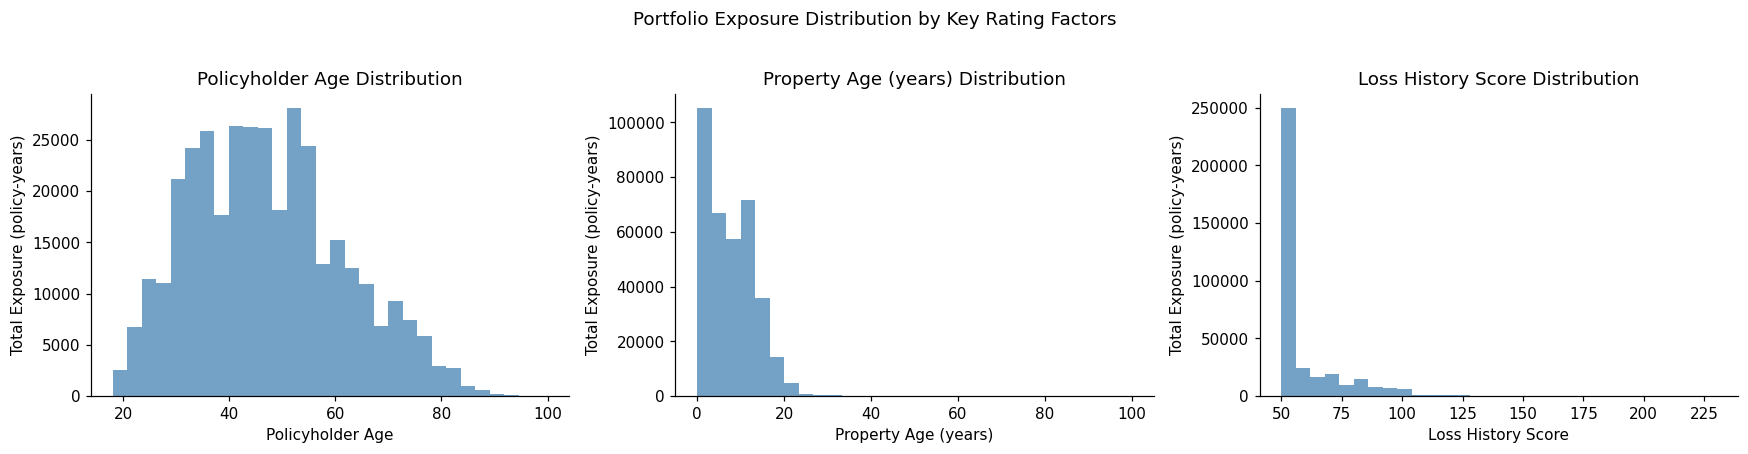

In [8]:
df = policy_df.to_pandas() # Read from our non-materialzied Snowpark DataFrame previously
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, label) in zip(axes, [
    ("POLICYHOLDER_AGE",  "Policyholder Age"),
    ("PROPERTY_AGE",      "Property Age (years)"),
    ("LOSS_HISTORY_SCORE","Loss History Score"),
]):
    ax.hist(df[col], bins=min(30, df[col].nunique()),
            weights=df["EXPOSURE"], color="steelblue", alpha=0.75, edgecolor="none")
    ax.set_xlabel(label)
    ax.set_ylabel("Total Exposure (policy-years)")
    ax.set_title(f"{label} Distribution")

plt.suptitle("Portfolio Exposure Distribution by Key Rating Factors", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Hands On

Get some experience materializing data and plotting it with matplotlib

## 5. Snowflake Feature Store and Datasets

In [10]:
from snowflake.ml.feature_store import FeatureStore, FeatureView, Entity, CreationMode

# ── 1. Load table and add target column ──────────────────────────────────────
ml_sdf = (
        snowpark_session.table("ML_INPUT_SNOWFLAKE")
        .with_column("PURE_PREMIUM", F.col("CLAIM_AMOUNT") / F.col("EXPOSURE"))
    )

# ── 3. Split (operates on Snowpark DataFrame — no data transfer) ──────────────
train_sdf, test_sdf = ml_sdf.random_split([0.75, 0.25], seed=0)

# ── 3. Entity ─────────────────────────────────────────────────────────────────
fs = FeatureStore(
    session=snowpark_session,
    database="COUNTRY_BANK_DEMO_DB",
    name="ACTUARIAL_PRICING",
    default_warehouse="COMPUTE_WH",
    creation_mode=CreationMode.CREATE_IF_NOT_EXIST,
)

policy_entity = Entity(name="POLICY", join_keys=["POLICY_ID"])
try:
    fs.register_entity(policy_entity)
except Exception:
    pass # Already exists

# ── 4. Feature view: all engineered features across all policies ──────────────
# Source is ml_sdf (full population, not the training split).
# Feature Store holds features for every entity; the train/test cut
# happens at dataset generation time via the spine.
fv = FeatureView(
    name="ACTUARIAL_FEATURES",
    entities=[policy_entity],
    feature_df=ml_sdf.select(["POLICY_ID"] + feature_cols), # THIS IS THE KEY LINE - FILL Feature View with data we engineered
    refresh_freq=None,
    desc="Engineered insurance rating facotrs. "
)
fv = fs.register_feature_view(
    feature_view=fv,
    version="1", # Make some changes, and update this!
    block=True,
    overwrite=True,
)

# ── 5. Training dataset: features joined onto the training spine ──────────────
# Only training-split POLICY_IDs are included; test_sdf stays withheld.
spine_df = train_sdf.select("POLICY_ID", "PURE_PREMIUM", "EXPOSURE")

training_dataset = fs.generate_dataset(
    name="ACTUARIAL_TRAINING",
    spine_df=spine_df,
    features=[fv],
    version="2", # <-- Update the data split, then increment this
    spine_label_cols=["PURE_PREMIUM", "EXPOSURE"],
    desc="Training split",
)

spine_df = test_sdf.select("POLICY_ID", "PURE_PREMIUM", "EXPOSURE")

validation_dataset = fs.generate_dataset(
    name="ACTUARIAL_VALIDATION",
    spine_df=spine_df,
    features=[fv],
    version="2", # <-- Update the data split, then increment this
    spine_label_cols=["PURE_PREMIUM", "EXPOSURE"],
    desc="Validation split",
)

## 6. GBM Benchmark

A Snowflake-native gradient boosting model trained directly on the pure premium.

In [11]:
from snowflake.ml.modeling.xgboost import XGBRegressor



train_ds_sdf = training_dataset.read.to_snowpark_dataframe()
test_ds_sdf = training_dataset.read.to_snowpark_dataframe()

_spine_cols = {"POLICY_ID", "PURE_PREMIUM", "EXPOSURE"}
feature_cols = [c for c in train_ds_sdf.columns if c not in _spine_cols]


# ── 3. Fit (training runs in the Snowflake warehouse) ─────────────────────────
gbm_sp = XGBRegressor(
        input_cols=feature_cols,
        label_cols=["PURE_PREMIUM"],
        output_cols=["PREDICTED_PURE_PREMIUM"],
        sample_weight_col="EXPOSURE",
        n_estimators=200,
        learning_rate=0.05,
        max_leaves=31,
        random_state=0,
        objective="reg:squarederror",
    )
gbm_sp.fit(train_ds_sdf)

    # ── 4. Predict + score (server-side aggregation) ──────────────────────────────
preds_sdf = gbm_sp.predict(test_ds_sdf)

metrics = preds_sdf.select(
        F.sqrt(F.avg(
            (F.col("PURE_PREMIUM") - F.col("PREDICTED_PURE_PREMIUM")) ** 2
        )).alias("RMSE"),
        F.avg(F.abs(
            F.col("PURE_PREMIUM") - F.col("PREDICTED_PURE_PREMIUM"))
        ).alias("MAE"),
    ).collect()[0]

print(f"Test RMSE : {metrics['RMSE']:>10.4f}")
print(f"Test MAE  : {metrics['MAE']:>10.4f}")

Package 'snowflake-telemetry-python' is not installed in the local environment. Your UDF might not work when the package is installed on the server but not on your local environment.


Test RMSE : 28820.2724
Test MAE  :   469.2698


## 7. Double-Lift Chart

The double-lift chart is a standard actuarial model validation tool:

1. Score all test policies with each model
2. Rank into 10 deciles (1 = lowest predicted risk, 10 = highest)
3. For each decile: compare exposure-weighted **predicted** vs. **observed** pure premium

**What to look for:**
- Both lines should rise monotonically from left (safest) to right (riskiest)
- Predicted and observed lines should track closely — a large gap means poor calibration in that risk segment
- The steeper the slope, the better the model discriminates risk

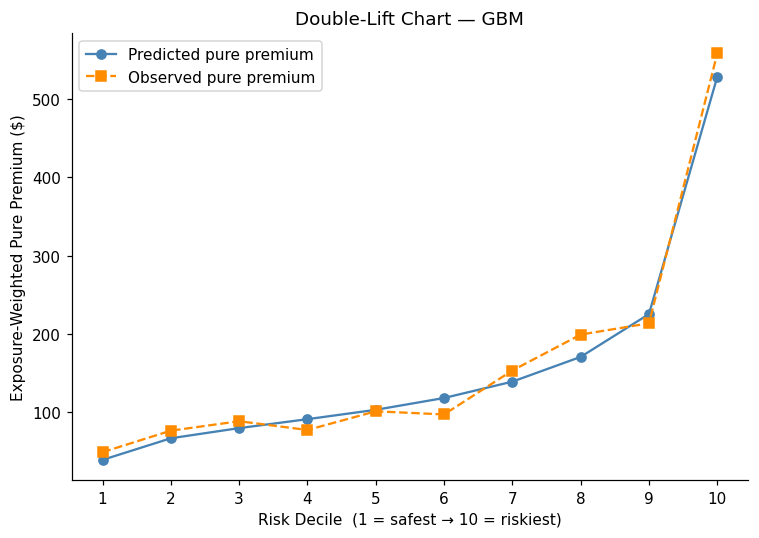

In [12]:
# y_pred_product = y_pred_product_test   # statsmodels Freq×Sev predictions
# y_pred_tweedie = glm_pp.predict(X_test)
df_test = gbm_sp.predict(test_sdf).to_pandas()
df_test["PurePremium"] = df_test["PURE_PREMIUM"]

y_pred_gbm     = df_test["PREDICTED_PURE_PREMIUM"].values

double_lift_chart(
    df_test,
    predictions_dict={
        "GBM":          y_pred_gbm,
    },
    n_bins=10,
)
plt.show()

## 8. Lorenz Curve & Gini Index

The Lorenz curve plots cumulative claim amounts against cumulative exposure,
where policies are ordered from **safest** (lowest predicted risk) to **riskiest**.

- **Random baseline** (diagonal): no discrimination ability
- **Oracle model** (upper bound): policies ranked by their actual observed losses
- **Our models**: the farther above the diagonal, the better the risk discrimination

The **Gini index** = area between the Lorenz curve and the diagonal (normalized to [0,1]).
Higher is better — it measures how well the model separates low-risk from high-risk policies.

> This chart is one of the primary deliverables actuaries produce for pricing reviews
> and regulatory model documentation.

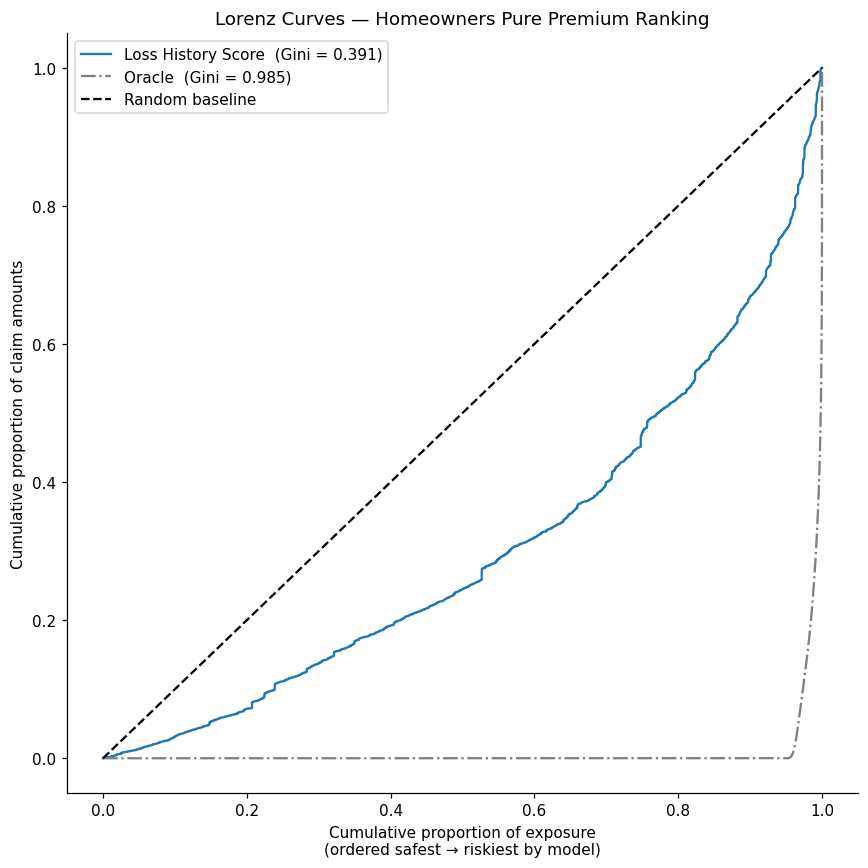

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

cum_exp, cum_claims = lorenz_curve(
        df_test["PurePremium"], y_pred_gbm, df_test["EXPOSURE"]
)
gini = 1 - 2 * auc(cum_exp, cum_claims)
ax.plot(cum_exp, cum_claims, label=f"{label}  (Gini = {gini:.3f})")

# Oracle upper bound
cum_exp, cum_claims = lorenz_curve(
    df_test["PurePremium"], df_test["PurePremium"], df_test["EXPOSURE"]
)
gini = 1 - 2 * auc(cum_exp, cum_claims)
ax.plot(cum_exp, cum_claims, linestyle="-.", color="gray",
        label=f"Oracle  (Gini = {gini:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random baseline")

ax.set(
    title="Lorenz Curves — Homeowners Pure Premium Ranking",
    xlabel="Cumulative proportion of exposure\n(ordered safest → riskiest by model)",
    ylabel="Cumulative proportion of claim amounts",
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 12. Next Steps — Snowflake MLOps Integration

The analysis above runs entirely in standard Python/sklearn — the same code your
team runs today. Here is what Snowflake adds on top:

| Capability | Snowflake Feature | Benefit |
|---|---|---|
| Distributed feature engineering | Snowpark DataFrames | Push computation to the warehouse — no data egress |
| Model versioning & metadata | ML Model Registry | Reproducibility for regulatory audit trail |
| Experiment tracking | ML Experiments | Compare runs across hyperparameter sweeps |
| Batch scoring at scale | Model Registry `.run()` | Score 700K+ policies in parallel |
| Online inference endpoint | Model Registry serving | Real-time pricing API |
| Shareable actuarial outputs | Streamlit in Snowflake | Interactive double-lift / Gini charts for product managers |
| Audit-ready lineage | Snowflake Horizon | Column-level lineage from source data → model → predictions |

The next notebook in this series will wire these capabilities into the workflow above.

In [15]:
from snowflake.ml.registry import Registry
from snowflake.ml.model.task import Task

registry = Registry(
    session=snowpark_session,
    database_name="COUNTRY_BANK_DEMO_DB",
    schema_name="ACTUARIAL_PRICING",
)

mv = registry.log_model(
    model=gbm_sp,
    model_name="HOMEOWNERS_PURE_PREMIUM_GBM",
    version_name="V2",
    task=Task.TABULAR_REGRESSION,
    comment="XGBoost pure premium model — homeowners actuarial pricing demo",
    metrics={
        "test_rmse": float(metrics["RMSE"]),
        "test_mae": float(metrics["MAE"])
    },
    sample_input_data=train_ds_sdf.limit(10),
)

Model logged successfully.: 100%|██████████| 6/6 [01:22<00:00, 13.72s/it]                          


## 13. Remote Compute

This is all well and good for a notebook, but let's imagine our project grows and we want to push this compute to a remote cluster and avoid any resource contention. For this we turn to MLJobs. First, we need to wrap up all of the training and other supporting code into either a single Python file or a Python module. 

Hands On: Use CoCo to do this. 

> @actuarial_pricing_demo.ipynb Take the training code from this notebook and extract it into a clean Python file with a single "train" entrypoint. This script is intended to run inside SPCS as an MLJob. Start from Section 7 where from loading the Snowflake dataset, and include everything through registering the model. 

Or use `train.py`

In [38]:
from snowflake.ml.jobs import submit_file

job = submit_file(
    # Use CoCo or see https://docs.snowflake.com/en/developer-guide/snowpark-ml/reference/latest/api/jobs/snowflake.ml.jobs.submit_file for the signature!
    "train.py",
    compute_pool="DEMO_POOL",
    stage_name="payload_stage",
    query_warehouse="COMPUTE_WH",
    args=["--ds-version=1"],
    session=session,
)
print(f"Submitted job {job.name}")
job.wait()
print(job.status)
print(job.get_logs())

Submitted job TRAIN_252689B6_MZBYOHP98218
DONE
Feature columns (75): ['PROPERTY_AGE_CLEAN_BIN_0', 'PROPERTY_AGE_CLEAN_BIN_1', 'PROPERTY_AGE_CLEAN_BIN_2', 'PROPERTY_AGE_CLEAN_BIN_3', 'PROPERTY_AGE_CLEAN_BIN_4'] ...
Model training complete
Validation RMSE : 11909.6730
Validation MAE  :   437.0846
2026-05-20 14:43:54,038 - INFO - Using non-live commit model version
2026-05-20 14:44:02,669 - INFO - Start packaging and uploading your model. It might take some time based on the size of the model.
2026-05-20 14:44:02,678 - INFO - Inferred Task: TABULAR_REGRESSION is used as task for this model version
2026-05-20 14:44:02,703 - INFO - Model signatures are auto inferred as:

{'predict': ModelSignature(
    inputs=[
        FeatureSpec(dtype=DataType.DOUBLE, name='PROPERTY_AGE_CLEAN_BIN_0', nullable=True),
        FeatureSpec(dtype=DataType.DOUBLE, name='PROPERTY_AGE_CLEAN_BIN_1', nullable=True),
        FeatureSpec(dtype=DataType.DOUBLE, name='PROPERTY_AGE_CLEAN_BIN_2', nullable=True),
        

In [29]:
session.get_current_role()

'"COUNTRY_BANK_DEMO_ROLE"'

## 14. Inference with Run Batch

In [29]:
from snowflake.ml.dataset import load_dataset
from snowflake.ml.model._client.model.batch_inference_specs import JobSpec, OutputSpec, SaveMode

validation_features_spdf = load_dataset(session, name="ACTUARIAL_VALIDATION", version="2").read.to_snowpark_dataframe(only_feature_cols=True)

registry = Registry(session=snowpark_session, database_name="COUNTRY_BANK_DEMO_DB", schema_name="ACTUARIAL_PRICING")
mv = registry.get_model("ACTUARIAL_GBM").default


batch_job = mv.run_batch(
    validation_features_spdf,
    compute_pool="DEMO_POOL",
    output_spec=OutputSpec(
        base_stage_location="@COUNTRY_BANK_DEMO_DB.ACTUARIAL_PRICING.OUTPUT_STAGE/ACTUARIAL_GBM/",
        mode=SaveMode.OVERWRITE,
    ),
    job_spec=JobSpec(
        replicas=1,
    ),
)

print(f"Batch job submitted: {batch_job.name}")
batch_job.wait()
print(f"Status: {batch_job.status}")
print(batch_job.get_logs())

Batch job submitted: BATCH_INFERENCE_FD3DFF3C_99A6_4A43_A058_9178EE4B68C9
Status: DONE
2026-05-20 14:24:36 [1] [INFO] /service/ray_inference_job.py:1222 Starting inference.
2026-05-20 14:24:42,349	INFO progress_bar.py:155 -- Progress bar disabled because stdout is a non-interactive terminal.
2026-05-20 14:24:47,781	INFO progress_bar.py:213 -- === Ray Data Progress {Parquet dataset sampling} ===
2026-05-20 14:24:47,781	INFO progress_bar.py:215 -- Parquet dataset sampling: Progress Completed 1 / 2
2026-05-20 14:24:48,311	INFO parquet_datasource.py:1048 -- Estimated parquet encoding ratio is 38.730.
2026-05-20 14:24:48,311	INFO parquet_datasource.py:1108 -- Estimated parquet reader batch size at 214406 rows
2026-05-20 14:24:53,289	INFO logging.py:397 -- Registered dataset logger for dataset dataset_3_0
2026-05-20 14:24:53,299	INFO streaming_executor.py:178 -- Starting execution of Dataset dataset_3_0. Full logs are in /tmp/ray/session_2026-05-20_14-24-26_536181_42/logs/ray-data
2026-05-20

In [39]:
mv = registry.get_model("ACTUARIAL_GBM").last()
explanations = mv.run(validation_features_spdf, function_name="explain")

In [40]:
type(explanations)

snowflake.snowpark.dataframe.DataFrame

In [48]:

from snowflake.ml.monitoring.explain_visualize import plot_force
explanations_pd = explanations.to_pandas()
validation_features_pd = validation_features_spdf.to_pandas()

In [59]:
policy_sdf.columns()

TypeError: 'list' object is not callable

In [65]:
explanations_pd_orig = explanations_pd.copy()

In [66]:
explanations_pd = explanations_pd.drop(columns=[c for c in explanations_pd if "_explanation" not in c])

In [67]:
policy_df.select(F.mean("CLAIM_AMOUNT")).collect()

[Row(AVG("CLAIM_AMOUNT")=76.94784182604168)]

In [ ]:
validation_features_pd

,POLICY_ID,PROPERTY_AGE_CLEAN_BIN_0,PROPERTY_AGE_CLEAN_BIN_1,PROPERTY_AGE_CLEAN_BIN_2,PROPERTY_AGE_CLEAN_BIN_3,PROPERTY_AGE_CLEAN_BIN_4,PROPERTY_AGE_CLEAN_BIN_5,PROPERTY_AGE_CLEAN_BIN_6,PROPERTY_AGE_CLEAN_BIN_7,PROPERTY_AGE_CLEAN_BIN_8,...,REGION_CODE_R93,REGION_CODE_R94,TERRITORY_CODE_A,TERRITORY_CODE_B,TERRITORY_CODE_C,TERRITORY_CODE_D,TERRITORY_CODE_E,TERRITORY_CODE_F,LOSS_HISTORY_SCORE_CLEAN,POPULATION_DENSITY_LOG_SCALED
0,2018413,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,100.0,1.687693
1,2018504,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,0.047564
2,2018533,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,60.0,-1.328696
3,2018597,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,-0.020835
4,2018627,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,50.0,0.180276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169346,2018151,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,50.0,1.514847
169347,2018160,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,-0.026478
169348,2018201,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,-0.181701
169349,2018202,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,-0.181701


In [73]:
plot_force(explanations_pd.iloc[10], validation_features_pd.drop(columns=["POLICY_ID"]).iloc[10])

alt.LayerChart(...)

In [46]:
explanations_pd.columns

Index(['POLICY_ID', 'PROPERTY_AGE_CLEAN_BIN_0', 'PROPERTY_AGE_CLEAN_BIN_1',
       'PROPERTY_AGE_CLEAN_BIN_2', 'PROPERTY_AGE_CLEAN_BIN_3',
       'PROPERTY_AGE_CLEAN_BIN_4', 'PROPERTY_AGE_CLEAN_BIN_5',
       'PROPERTY_AGE_CLEAN_BIN_6', 'PROPERTY_AGE_CLEAN_BIN_7',
       'PROPERTY_AGE_CLEAN_BIN_8',
       ...
       '"REGION_CODE_R93_explanation"', '"REGION_CODE_R94_explanation"',
       '"TERRITORY_CODE_A_explanation"', '"TERRITORY_CODE_B_explanation"',
       '"TERRITORY_CODE_C_explanation"', '"TERRITORY_CODE_D_explanation"',
       '"TERRITORY_CODE_E_explanation"', '"TERRITORY_CODE_F_explanation"',
       '"LOSS_HISTORY_SCORE_CLEAN_explanation"',
       '"POPULATION_DENSITY_LOG_SCALED_explanation"'],
      dtype='object', length=151)